# Advanced Smartwatch Data Pipeline v2.0

Professional data engineering pipeline with:
- Data validation & quality checks
- Structured logging
- Schema validation
- Feature engineering
- Error handling
- Pipeline reporting

---

## Step 1: Setup & Configuration

Let's import libraries and define our pipeline configuration.

In [2]:
import pandas as pd
import numpy as np
import os
import logging
from datetime import datetime
import json
import matplotlib.pyplot as plt
import seaborn as sns
import re
from logging.handlers import RotatingFileHandler
import warnings
warnings.filterwarnings('ignore')

# Setup matplotlib
plt.style.use('seaborn-v0_8')

# %% [markdown]
# ## Setup Logging

# %%
def setup_logging(log_dir='data/logs'):
    """Set up structured logging for the pipeline"""
    os.makedirs(log_dir, exist_ok=True)
    
    logger = logging.getLogger('smartwatch_pipeline')
    logger.setLevel(logging.DEBUG)
    
    # File handler with rotation
    log_file = os.path.join(log_dir, f'pipeline_{datetime.now().strftime("%Y%m%d")}.log')
    file_handler = RotatingFileHandler(log_file, maxBytes=10*1024*1024, backupCount=5)
    file_handler.setLevel(logging.DEBUG)
    
    # Console handler
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    
    # Formatter
    formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)
    
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    
    return logger

logger = setup_logging()
logger.info("Starting Smartwatch Pipeline v2.0")

# %% [markdown]
# ## Configuration

# %%
# Configuration
CONFIG = {
    'input_file': 'smartwatches.csv',
    'raw_dir': 'data/raw',
    'processed_dir': 'data/processed',
    'log_dir': 'data/logs',
    'report_dir': 'data/reports'
}

# Create directories
for dir_name in CONFIG.values():
    if isinstance(dir_name, str) and '/' in dir_name:
        os.makedirs(dir_name, exist_ok=True)

logger.info("Configuration loaded and directories created")

# %% [markdown]
# ## Schema Definition

# %%
EXPECTED_SCHEMA = {
    'Brand': 'object',
    'Current Price': 'float64',
    'Original Price': 'float64',
    'Discount Percentage': 'float64',
    'Rating': 'float64',
    'Number OF Ratings': 'float64',
    'Model Name': 'object',
    'Dial Shape': 'object',
    'Strap Color': 'object',
    'Strap Material': 'object',
    'Touchscreen': 'object',
    'Battery Life (Days)': 'float64',
    'Bluetooth': 'object',
    'Display Size': 'object',
    'Weight': 'object'
}

def validate_schema(df, expected_schema):
    """Validate that DataFrame matches expected schema"""
    issues = []
    for col, dtype in expected_schema.items():
        if col not in df.columns:
            issues.append(f"Missing expected column: {col}")
        elif df[col].dtype != dtype:
            issues.append(f"Column {col} is {df[col].dtype}, expected {dtype}")
    return issues

# %% [markdown]
# ## Helper Functions for JSON Serialization

# %%
def convert_to_serializable(obj):
    """Convert numpy/pandas types to Python native types for JSON serialization"""
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    return obj


2026-08-26 17:55:43,411 - smartwatch_pipeline - INFO - Starting Smartwatch Pipeline v2.0
2026-08-26 17:55:43,419 - smartwatch_pipeline - INFO - Configuration loaded and directories created


In [3]:

# %% [markdown]
# ## Step 2: Data Ingestion & Raw Storage

# %%
# Load raw data
try:
    df_raw = pd.read_csv(CONFIG['input_file'])
    logger.info(f"Loaded raw data: {len(df_raw)} records, {len(df_raw.columns)} columns")
except FileNotFoundError:
    logger.error(f"Input file {CONFIG['input_file']} not found")
    raise
except pd.errors.EmptyDataError:
    logger.error("Input file is empty")
    raise

# Save raw copy
df_raw.to_csv(f"{CONFIG['raw_dir']}/smartwatches_raw.csv", index=False)
logger.info(f"Raw data saved to {CONFIG['raw_dir']}/smartwatches_raw.csv")

# Show raw data sample
logger.info("Raw data sample:")
print(df_raw.head(10))

2026-08-26 17:55:55,719 - smartwatch_pipeline - INFO - Loaded raw data: 450 records, 16 columns
2026-08-26 17:55:55,737 - smartwatch_pipeline - INFO - Raw data saved to data/raw/smartwatches_raw.csv
2026-08-26 17:55:55,739 - smartwatch_pipeline - INFO - Raw data sample:


   Unnamed: 0       Brand  Current Price  Original Price  Discount Percentage  \
0           0       noise        82990.0         89900.0             7.686318   
1           1  fire-boltt         3799.0         16999.0            77.651627   
2           2        boat         1999.0          7990.0            74.981227   
3           3  fire-boltt         1799.0         19999.0            91.004550   
4           4       noise         1599.0          4999.0            68.013603   
5           5       noise         1499.0          3999.0            62.515629   
6           6       noise         1999.0          4999.0            60.012002   
7           7       noise         1799.0          3999.0            55.013753   
8           8       noise         1999.0          6499.0            69.241422   
9           9       noise         1999.0          5999.0            66.677780   

   Rating  Number OF Ratings                              Model Name  \
0     4.0               65.0   Wrb-s


VALIDATION REPORT:
Total records: 450
Total columns: 16
Duplicate records: 0

Missing values:
  Current Price: 10
  Original Price: 73
  Discount Percentage: 73
  Rating: 6
  Number OF Ratings: 59
  Model Name: 35
  Dial Shape: 123
  Strap Color: 123
  Strap Material: 69
  Touchscreen: 37
  Battery Life (Days): 32
  Bluetooth: 6
  Display Size: 30
  Weight: 186


<Figure size 1000x600 with 0 Axes>

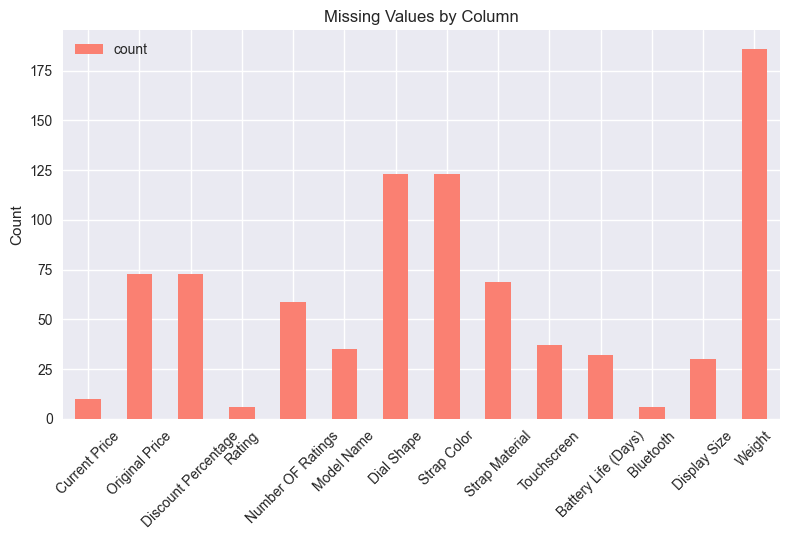

In [4]:
# %% [markdown]
# ## Step 3: Data Validation & Quality Checks

# %%
validation_results = {
    'total_records': len(df_raw),
    'total_columns': len(df_raw.columns),
    'missing_values': {},
    'duplicates': df_raw.duplicated().sum(),
    'column_names': list(df_raw.columns)
}

# Check missing values
for col in df_raw.columns:
    missing = df_raw[col].isnull().sum()
    if missing > 0:
        validation_results['missing_values'][col] = missing

# Schema validation
schema_issues = validate_schema(df_raw, EXPECTED_SCHEMA)
if schema_issues:
    logger.warning("Schema validation issues:")
    for issue in schema_issues:
        logger.warning(f"  {issue}")
validation_results['schema_issues'] = schema_issues

# Display validation results
print("\nVALIDATION REPORT:")
print(f"Total records: {validation_results['total_records']}")
print(f"Total columns: {validation_results['total_columns']}")
print(f"Duplicate records: {validation_results['duplicates']}")

if validation_results['missing_values']:
    print("\nMissing values:")
    for col, count in validation_results['missing_values'].items():
        print(f"  {col}: {count}")

# Visualize missing values
if validation_results['missing_values']:
    plt.figure(figsize=(10, 6))
    missing_df = pd.DataFrame.from_dict(validation_results['missing_values'], orient='index', columns=['count'])
    missing_df.plot(kind='bar', color='salmon')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['report_dir']}/missing_values.png")
    plt.show()

In [5]:
# %% [markdown]
# ## Step 4: Data Cleaning & Transformation

# %%
df_clean = df_raw.copy()

# 1. Standardize column names
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')
logger.info("Column names standardized")

# 2. Convert numeric columns
numeric_cols = ['current_price', 'original_price', 'discount_percentage', 'rating', 'number_of_ratings']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        logger.debug(f"Converted {col} to numeric")

# 3. Remove duplicates
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed = before_dedup - len(df_clean)
if removed > 0:
    logger.info(f"Removed {removed} duplicate rows")
else:
    logger.info("No duplicate rows found")
# 4. Handle missing values intelligently
def handle_missing_values(df):
    """Intelligently handle missing values"""
    df_handled = df.copy()
    
    # Numeric columns - impute with median
    for col in df_handled.select_dtypes(include=['float64', 'int64']).columns:
        if df_handled[col].isnull().sum() > 0:
            median_val = df_handled[col].median()
            df_handled[col].fillna(median_val, inplace=True)
            logger.info(f"Imputed {col} with median: {median_val:.2f}")
    
    # Categorical columns - impute with mode
    for col in df_handled.select_dtypes(include=['object']).columns:
        if df_handled[col].isnull().sum() > 0:
            mode_val = df_handled[col].mode()[0] if not df_handled[col].mode().empty else "Unknown"
            df_handled[col].fillna(mode_val, inplace=True)
            logger.info(f"Imputed {col} with mode: {mode_val}")
    
    return df_handled

df_clean = handle_missing_values(df_clean)

print("\nCleaned data summary:")
print(f"Clean columns: {list(df_clean.columns)}")
print(f"Records after cleaning: {len(df_clean)}")

# Show cleaned data sample
print("\nSample of cleaned data:")
print(df_clean.head())

2026-08-26 17:56:15,624 - smartwatch_pipeline - INFO - Column names standardized
2026-08-26 17:56:15,641 - smartwatch_pipeline - INFO - No duplicate rows found
2026-08-26 17:56:15,647 - smartwatch_pipeline - INFO - Imputed current_price with median: 3999.00
2026-08-26 17:56:15,652 - smartwatch_pipeline - INFO - Imputed original_price with median: 7999.00
2026-08-26 17:56:15,655 - smartwatch_pipeline - INFO - Imputed discount_percentage with median: 54.55
2026-08-26 17:56:15,658 - smartwatch_pipeline - INFO - Imputed rating with median: 4.10
2026-08-26 17:56:15,661 - smartwatch_pipeline - INFO - Imputed number_of_ratings with median: 996.00
2026-08-26 17:56:15,664 - smartwatch_pipeline - INFO - Imputed battery_life_(days) with median: 17.50
2026-08-26 17:56:15,672 - smartwatch_pipeline - INFO - Imputed model_name with mode: beast pro
2026-08-26 17:56:15,676 - smartwatch_pipeline - INFO - Imputed dial_shape with mode: Circle
2026-08-26 17:56:15,681 - smartwatch_pipeline - INFO - Imputed 


Cleaned data summary:
Clean columns: ['unnamed:_0', 'brand', 'current_price', 'original_price', 'discount_percentage', 'rating', 'number_of_ratings', 'model_name', 'dial_shape', 'strap_color', 'strap_material', 'touchscreen', 'battery_life_(days)', 'bluetooth', 'display_size', 'weight']
Records after cleaning: 450

Sample of cleaned data:
   unnamed:_0       brand  current_price  original_price  discount_percentage  \
0           0       noise        82990.0         89900.0             7.686318   
1           1  fire-boltt         3799.0         16999.0            77.651627   
2           2        boat         1999.0          7990.0            74.981227   
3           3  fire-boltt         1799.0         19999.0            91.004550   
4           4       noise         1599.0          4999.0            68.013603   

   rating  number_of_ratings                              model_name  \
0     4.0               65.0   Wrb-sw-colorfitpro4alpha-std-rgld_pnk   
1     4.3            20788.

In [6]:
# %% [markdown]
# ## Step 5: Feature Engineering

# %%
df_enriched = df_clean.copy()

# Feature 1: Price tiers
if 'current_price' in df_enriched.columns:
    df_enriched['price_tier'] = pd.cut(
        df_enriched['current_price'],
        bins=[0, 1000, 5000, 10000, 50000, np.inf],
        labels=['Budget', 'Entry', 'Mid-Range', 'Premium', 'Luxury']
    )
    logger.info("Created price_tier")

# Feature 2: Discount categories
if 'discount_percentage' in df_enriched.columns:
    df_enriched['discount_category'] = pd.cut(
        df_enriched['discount_percentage'],
        bins=[-np.inf, 0, 20, 50, 80, np.inf],
        labels=['Price_Increase', 'Small_Discount', 'Moderate_Discount', 'Large_Discount', 'Extreme_Discount']
    )
    logger.info("Created discount_category")

# Feature 3: Rating categories
if 'rating' in df_enriched.columns:
    df_enriched['rating_category'] = pd.cut(
        df_enriched['rating'],
        bins=[0, 2, 3, 4, 4.5, 5],
        labels=['Poor', 'Fair', 'Good', 'Very_Good', 'Excellent']
    )
    logger.info("Created rating_category")

# Feature 4: Discount amount
if 'current_price' in df_enriched.columns and 'original_price' in df_enriched.columns:
    df_enriched['discount_amount'] = df_enriched['original_price'] - df_enriched['current_price']
    logger.info("Created discount_amount")

# Feature 5: Parse display size to inches
def parse_display_size(size_str):
    """Extract numeric display size in inches"""
    if pd.isna(size_str):
        return np.nan
    match = re.search(r'([\d.]+)\s*(?:inch|inches|")', str(size_str))
    if match:
        return float(match.group(1))
    return np.nan

if 'display_size' in df_enriched.columns:
    df_enriched['display_size_inches'] = df_enriched['display_size'].apply(parse_display_size)
    logger.info("Created display_size_inches")

# Feature 6: Parse weight ranges to numeric grams
def parse_weight(weight_str):
    """Convert weight range to numeric value in grams"""
    if pd.isna(weight_str):
        return np.nan
    numbers = re.findall(r'(\d+)', str(weight_str))
    if len(numbers) == 1:
        return float(numbers[0])
    elif len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    return np.nan

if 'weight' in df_enriched.columns:
    df_enriched['weight_grams'] = df_enriched['weight'].apply(parse_weight)
    logger.info("Created weight_grams")

# Feature 7: Boolean indicators
if 'bluetooth' in df_enriched.columns:
    df_enriched['has_bluetooth'] = (df_enriched['bluetooth'] == 'Yes').astype(int)
    logger.info("Created has_bluetooth")

if 'touchscreen' in df_enriched.columns:
    df_enriched['has_touchscreen'] = (df_enriched['touchscreen'] == 'Yes').astype(int)
    logger.info("Created has_touchscreen")

# Feature 8: Value for money score (rating relative to price)
if 'rating' in df_enriched.columns and 'current_price' in df_enriched.columns:
    median_price = df_enriched['current_price'].median()
    df_enriched['value_score'] = df_enriched['rating'] / (df_enriched['current_price'] / median_price)
    logger.info("Created value_score")

# Feature 9: Brand popularity score
if 'brand' in df_enriched.columns and 'number_of_ratings' in df_enriched.columns:
    brand_popularity = df_enriched.groupby('brand')['number_of_ratings'].sum().rank(pct=True)
    df_enriched['brand_popularity_score'] = df_enriched['brand'].map(brand_popularity)
    logger.info("Created brand_popularity_score")

print("\nFeature engineering complete. New features added.")
print(f"Total columns now: {len(df_enriched.columns)}")
print("New features:", [c for c in df_enriched.columns if c not in df_clean.columns])

# Show enriched data sample
print("\nSample of enriched data (selected columns):")
print(df_enriched[['brand', 'current_price', 'price_tier', 'rating', 'rating_category',
                   'discount_percentage', 'discount_category', 'value_score']].head(10))


2026-08-26 17:56:25,985 - smartwatch_pipeline - INFO - Created price_tier
2026-08-26 17:56:25,990 - smartwatch_pipeline - INFO - Created discount_category
2026-08-26 17:56:25,997 - smartwatch_pipeline - INFO - Created rating_category
2026-08-26 17:56:26,001 - smartwatch_pipeline - INFO - Created discount_amount
2026-08-26 17:56:26,009 - smartwatch_pipeline - INFO - Created display_size_inches
2026-08-26 17:56:26,015 - smartwatch_pipeline - INFO - Created weight_grams
2026-08-26 17:56:26,019 - smartwatch_pipeline - INFO - Created has_bluetooth
2026-08-26 17:56:26,022 - smartwatch_pipeline - INFO - Created has_touchscreen
2026-08-26 17:56:26,025 - smartwatch_pipeline - INFO - Created value_score
2026-08-26 17:56:26,035 - smartwatch_pipeline - INFO - Created brand_popularity_score



Feature engineering complete. New features added.
Total columns now: 26
New features: ['price_tier', 'discount_category', 'rating_category', 'discount_amount', 'display_size_inches', 'weight_grams', 'has_bluetooth', 'has_touchscreen', 'value_score', 'brand_popularity_score']

Sample of enriched data (selected columns):
        brand  current_price price_tier  rating rating_category  \
0       noise        82990.0     Luxury     4.0            Good   
1  fire-boltt         3799.0      Entry     4.3       Very_Good   
2        boat         1999.0      Entry     3.8            Good   
3  fire-boltt         1799.0      Entry     4.3       Very_Good   
4       noise         1599.0      Entry     4.1       Very_Good   
5       noise         1499.0      Entry     4.0            Good   
6       noise         1999.0      Entry     4.1       Very_Good   
7       noise         1799.0      Entry     4.0            Good   
8       noise         1999.0      Entry     4.1       Very_Good   
9       


SUMMARY STATISTICS:
Total smartwatches: 450
Unique brands: 18
Average price: $12553.14
Average rating: 4.03


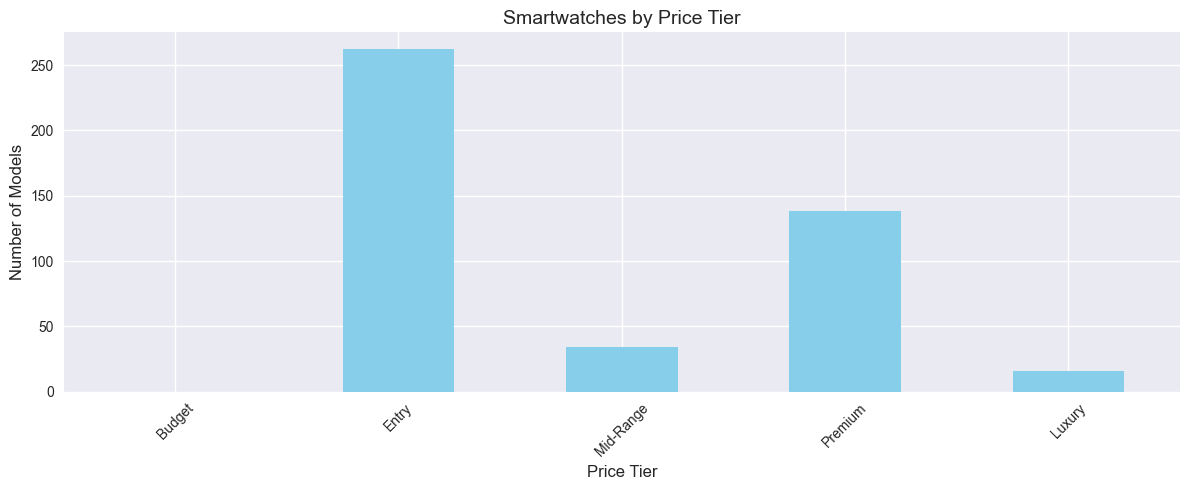

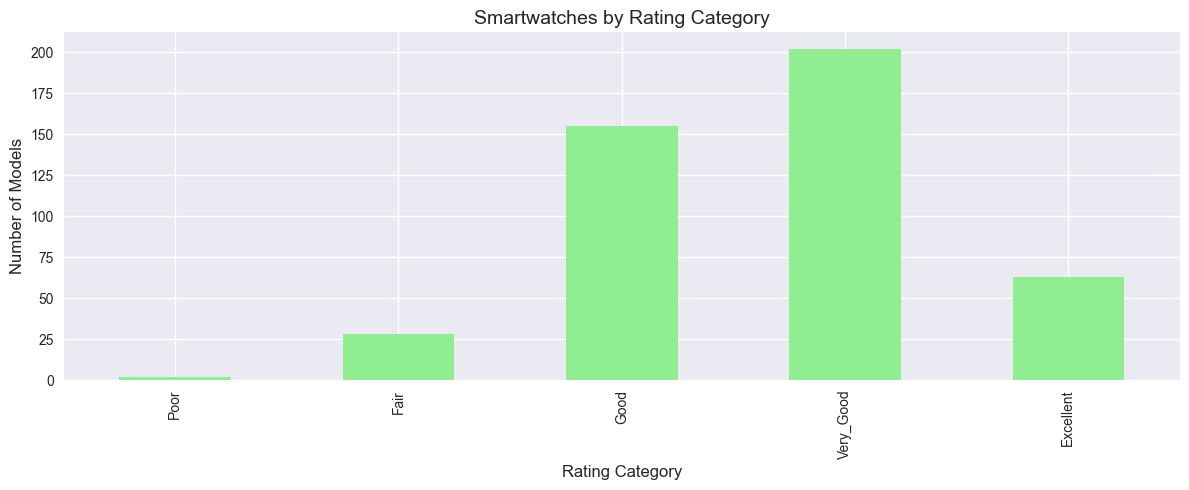

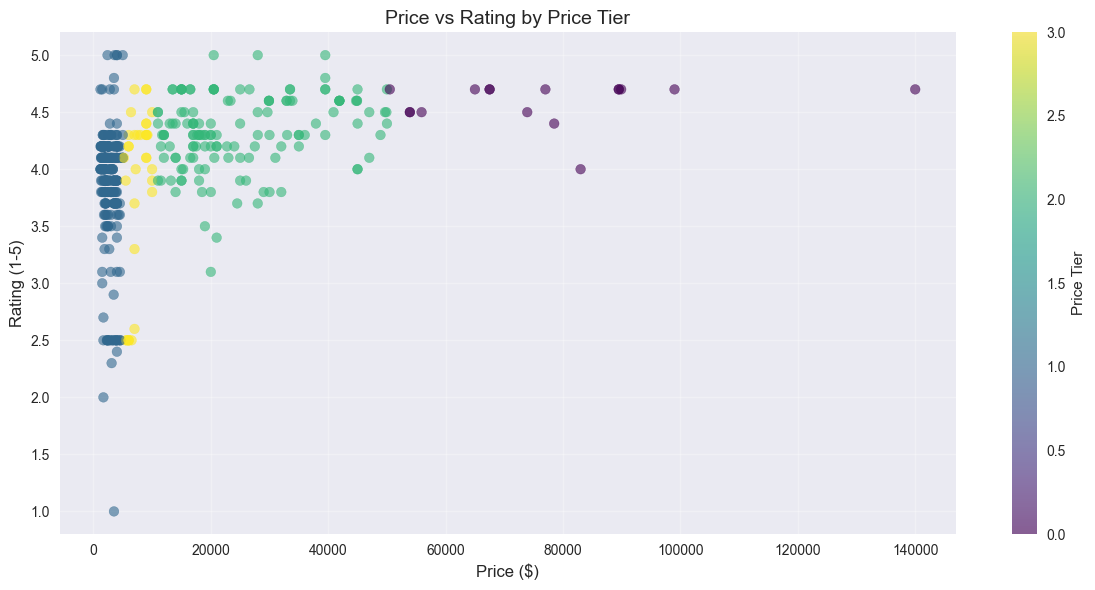

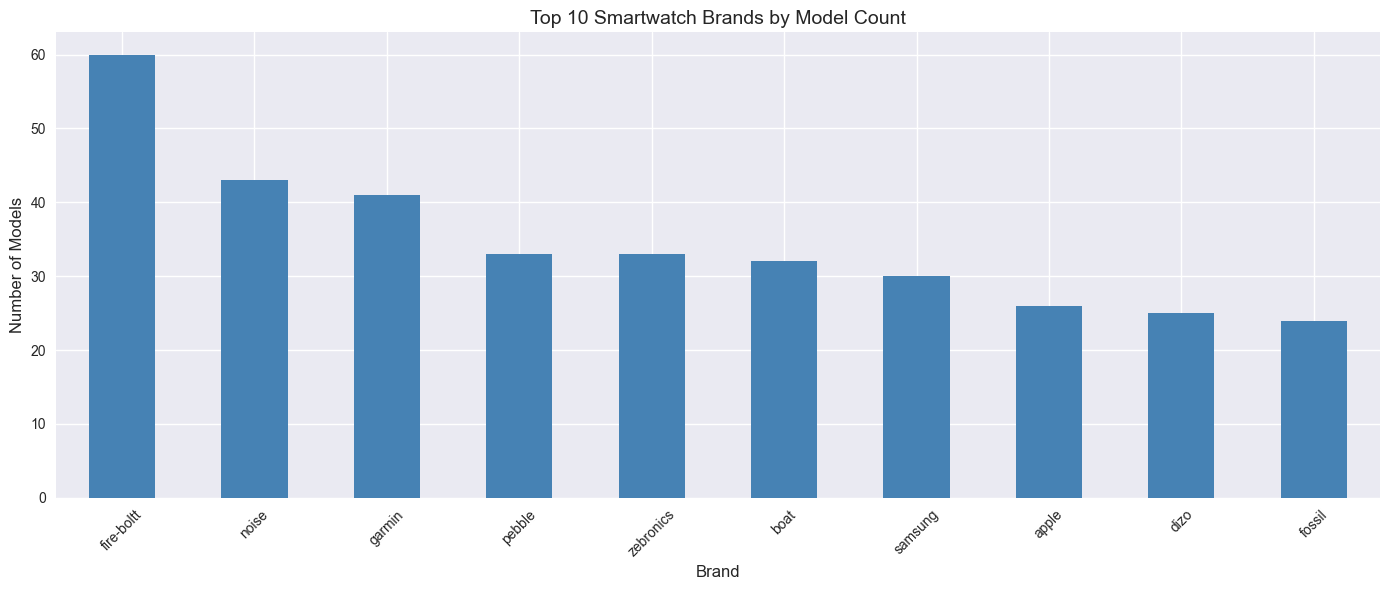

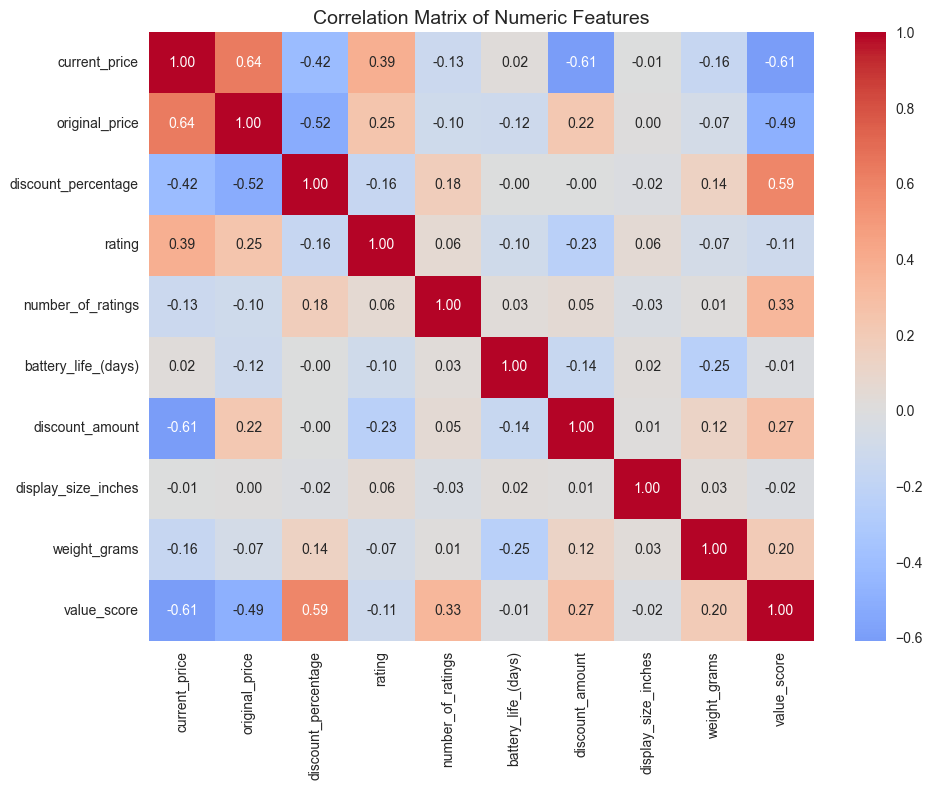

In [7]:
# %% [markdown]
# ## Step 6: Analysis & Visualization

# %%
# Summary statistics
print("\nSUMMARY STATISTICS:")
print(f"Total smartwatches: {len(df_enriched)}")
if 'brand' in df_enriched.columns:
    print(f"Unique brands: {df_enriched['brand'].nunique()}")
if 'current_price' in df_enriched.columns:
    print(f"Average price: ${df_enriched['current_price'].mean():.2f}")
if 'rating' in df_enriched.columns:
    print(f"Average rating: {df_enriched['rating'].mean():.2f}")

# Plot 1: Price Tier Distribution
if 'price_tier' in df_enriched.columns:
    plt.figure(figsize=(12, 5))
    df_enriched['price_tier'].value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.title('Smartwatches by Price Tier', fontsize=14)
    plt.xlabel('Price Tier', fontsize=12)
    plt.ylabel('Number of Models', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['report_dir']}/price_tier_distribution.png")
    plt.show()
# Plot 2: Rating Categories
if 'rating_category' in df_enriched.columns:
    plt.figure(figsize=(12, 5))
    df_enriched['rating_category'].value_counts().sort_index().plot(kind='bar', color='lightgreen')
    plt.title('Smartwatches by Rating Category', fontsize=14)
    plt.xlabel('Rating Category', fontsize=12)
    plt.ylabel('Number of Models', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['report_dir']}/rating_categories.png")
    plt.show()

# Plot 3: Price vs Rating with tiers
if 'current_price' in df_enriched.columns and 'rating' in df_enriched.columns and 'price_tier' in df_enriched.columns:
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(df_enriched['current_price'], df_enriched['rating'],
                         alpha=0.6, c=pd.factorize(df_enriched['price_tier'])[0], cmap='viridis')
    plt.colorbar(scatter, label='Price Tier')
    plt.title('Price vs Rating by Price Tier', fontsize=14)
    plt.xlabel('Price ($)', fontsize=12)
    plt.ylabel('Rating (1-5)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['report_dir']}/price_vs_rating.png")
    plt.show()
# Additional plot: Top brands by model count
plt.figure(figsize=(14, 6))
brand_counts = df_enriched['brand'].value_counts().head(10)
brand_counts.plot(kind='bar', color='steelblue')
plt.title('Top 10 Smartwatch Brands by Model Count', fontsize=14)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CONFIG['report_dir']}/top_brands.png")
plt.show()

# Correlation heatmap
numeric_cols = ['current_price', 'original_price', 'discount_percentage', 'rating',
                'number_of_ratings', 'battery_life_(days)', 'discount_amount',
                'display_size_inches', 'weight_grams', 'value_score']
numeric_cols_present = [c for c in numeric_cols if c in df_enriched.columns]
if len(numeric_cols_present) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = df_enriched[numeric_cols_present].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix of Numeric Features', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['report_dir']}/correlation_matrix.png")
    plt.show()

In [8]:
# %% [markdown]
# ## Step 7: Save Processed Data & Generate Report

# %%
# Save in multiple formats
df_enriched.to_csv(f"{CONFIG['processed_dir']}/smartwatches_clean.csv", index=False)
df_enriched.to_json(f"{CONFIG['processed_dir']}/smartwatches_clean.json", orient='records', indent=2)
logger.info(f"Processed data saved to {CONFIG['processed_dir']}/")

# Generate pipeline report
pipeline_report = {
    'pipeline_name': 'Advanced Smartwatch Pipeline',
    'version': '2.0',
    'run_date': datetime.now().isoformat(),
    'validation': validation_results,
    'summary': {
        'records_processed': len(df_enriched),
        'columns_final': len(df_enriched.columns),
        'features_created': ['price_tier', 'discount_category', 'rating_category', 'discount_amount',
                             'display_size_inches', 'weight_grams', 'has_bluetooth', 'has_touchscreen',
                             'value_score', 'brand_popularity_score']
    }
}

# Save report with serialization handling
report_file = f"{CONFIG['report_dir']}/pipeline_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(report_file, 'w') as f:
    json.dump(pipeline_report, f, indent=2, default=convert_to_serializable)
logger.info(f"Pipeline report saved to {report_file}")

# Generate data quality report
def generate_data_quality_report(df):
    """Generate detailed data quality metrics"""
    report = {
        'timestamp': datetime.now().isoformat(),
        'total_records': len(df),
        'total_columns': len(df.columns),
        'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2,
        'duplicate_count': df.duplicated().sum(),
        'column_quality': {}
    }
    
    for col in df.columns:
        col_info = {
            'missing_count': int(df[col].isnull().sum()),
            'missing_pct': float(df[col].isnull().mean() * 100),
            'unique_count': int(df[col].nunique()),
            'dtype': str(df[col].dtype),
        }
        if pd.api.types.is_numeric_dtype(df[col]):
            col_info.update({
                'min': float(df[col].min()) if not df[col].isnull().all() else None,
                'max': float(df[col].max()) if not df[col].isnull().all() else None,
                'mean': float(df[col].mean()) if not df[col].isnull().all() else None,
                'std': float(df[col].std()) if not df[col].isnull().all() else None
            })
        report['column_quality'][col] = col_info
    
    return report

quality_report = generate_data_quality_report(df_enriched)
quality_file = f"{CONFIG['report_dir']}/data_quality_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(quality_file, 'w') as f:
    json.dump(quality_report, f, indent=2, default=convert_to_serializable)
logger.info(f"Data quality report saved to {quality_file}")

# %% [markdown]
# ## Pipeline Completion

# %%
logger.info("Pipeline completed successfully")
print("\n" + "="*60)
print("PIPELINE EXECUTION COMPLETE")
print("="*60)
print(f"Processed {len(df_enriched)} records")
print(f"Output files saved in {CONFIG['processed_dir']}")
print(f"Reports saved in {CONFIG['report_dir']}")
print("="*60)

2026-08-26 17:56:54,832 - smartwatch_pipeline - INFO - Processed data saved to data/processed/
2026-08-26 17:56:54,836 - smartwatch_pipeline - INFO - Pipeline report saved to data/reports/pipeline_report_20260826_175654.json
2026-08-26 17:56:54,874 - smartwatch_pipeline - INFO - Data quality report saved to data/reports/data_quality_20260826_175654.json
2026-08-26 17:56:54,876 - smartwatch_pipeline - INFO - Pipeline completed successfully



PIPELINE EXECUTION COMPLETE
Processed 450 records
Output files saved in data/processed
Reports saved in data/reports




### Workflow:

1. **Data Ingestion**: Loaded and preserved raw data
2. **Data Validation**: Checked data quality and integrity
3. **Data Cleaning**: Standardized and prepared data
4. **Feature Engineering**: Created meaningful features
5. **Analysis**: Explored insights with visualizations
6. **Storage**: Saved data in multiple formats
7. **Reporting**: Documented the pipeline run

### Files Created:
- `data/raw/smartwatches_raw.csv` - Original data
- `data/processed/smartwatches_clean.csv` - Cleaned & enriched data (CSV)
- `data/processed/smartwatches_clean.json` - Cleaned & enriched data (JSON)
- `data/reports/pipeline_report_*.json` - Pipeline documentation